I need to create a visualization for the model in chapter 2:

- rectangular basin as an idealized representation of the Ocean from $65\degree$ S to $65 \degree$ N latitude
- coord system: z = depth, x = zonal, y =meridional
- positive z upward, positive x northward, positive y westward (into page)
- periodic in zonal 
- topographic barrier - hill in "southern ocean" lets say at -Lx/4
- buoyancy forcing in f(x) hyperbolic tan
- wind forxing in zonal direction f(y) gaussian
- blocking continents


I want three plots vertically next to each other or whatever
1. showing geometry : the hill, labels for southern ocean, equator, and northern whatever
2. showing the buoyancy forcing for chapter 2, and the one in a diff color for summer/winter for chapter 3
3. the wind forcing

each plot should have x y labels the first two plots are a slice of the xz plane, the third is a slice of the yz plane


In [1]:
using CairoMakie

In [47]:
# Parameters
L = 8.0       # domain length
b = 1.0       # peak value
ϵ = 1e-6      # close to ±1

# Compute constants for tanh transform
β = atanh(1 - ϵ)
α = (2 / L) * (β - atanh(-1 + ϵ))

# Define forcing function
function bforce(x, b, α, β)
    if x < 0
        return b * tanh(α * (x + L/3))
    else
        return b
    end
end

function bforcech1(x, b)
    return b * sin(π * x / L)
end 

# Create data
x = range(-L/2, L/2; length=500)
y = bforce.(x, b, α, β);


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/hfdrake/.julia/packages/Makie/UjJJY/src/scenes.jl:238


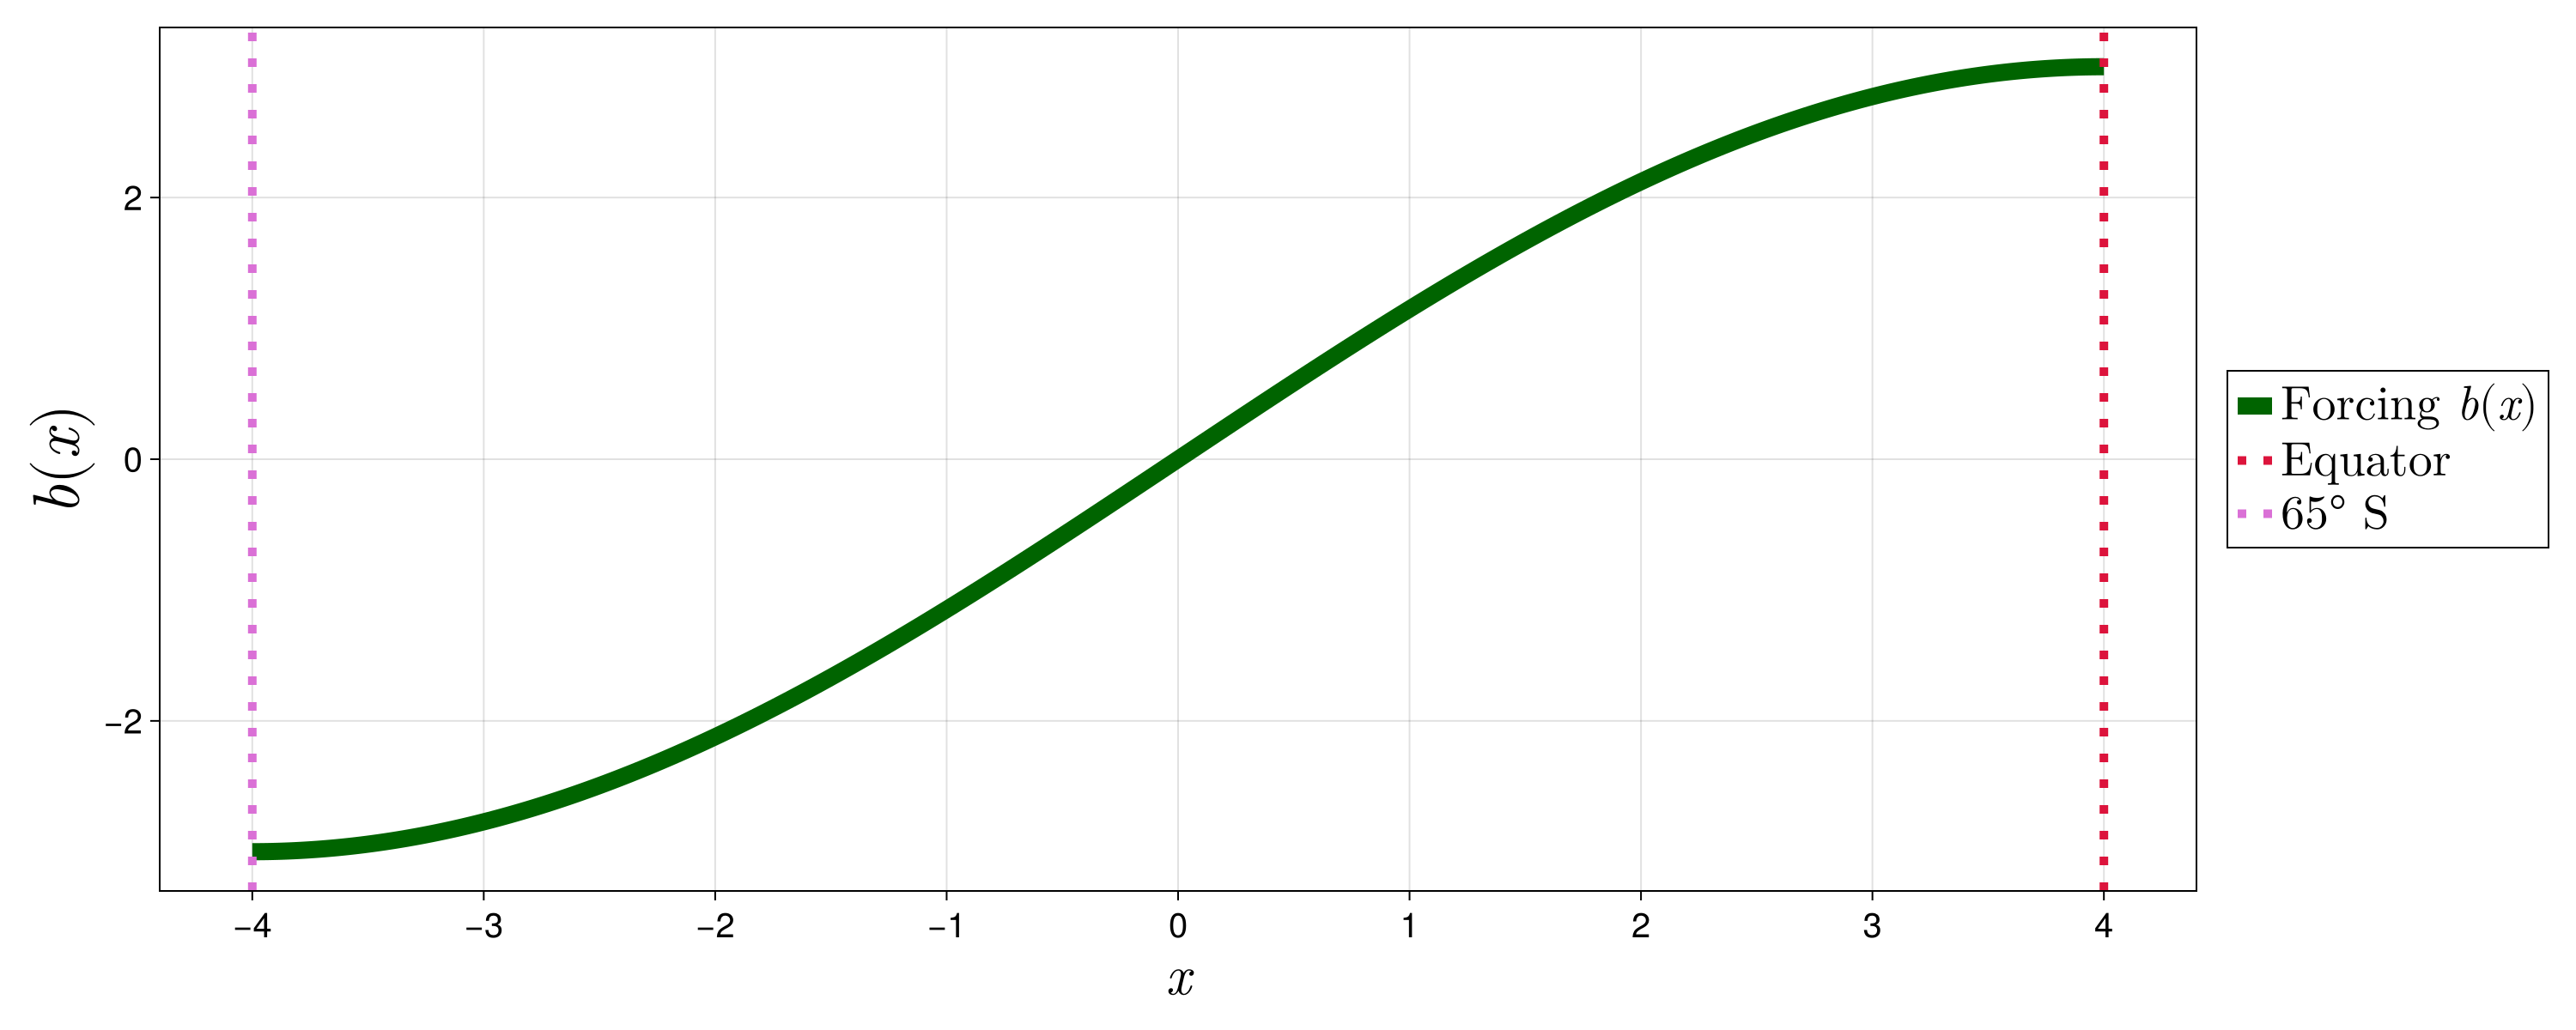

In [3]:
y2 = bforcech1.(x, b)
#plot chapter 1 forcing
fig_ch1 = Figure(resolution=(1500, 600))
ax = Axis(fig_ch1[1, 1],
    xlabel=L"x",
    ylabel=L"b(x)",
    xticks=-L/2:1:L/2)
lines!(ax, x, y2, color=:darkgreen, linewidth=10, label=L"\text{Forcing } b(x)")
vlines!(ax, [4], linestyle=:dot, color=:crimson, label=L"\text{Equator}", linewidth=5)
#vlines!(ax, [-2], linestyle=:dot, color=:darkblue, label=L"\text{End Southern Ocean Boundary}", linewidth=5)
vlines!(ax, [-4], linestyle=:dot, color=:orchid, label=L"65°\text{ S}", linewidth=5)

Legend(fig_ch1[1,2], ax, labelsize=28)

ax.xlabelsize = 32
ax.ylabelsize = 38
ax.xticklabelsize = 20
ax.yticklabelsize = 20

fig_ch1

In [68]:
#okay we need to define four different functions 

#b background
#b background is just bstar


function bsw(x,b)
    #this function is b season winter
    #when multiplied by seasonal sine func and added to b_bg we get b_surf winter
    return (3/2 * b * tanh(2(x+8/3))) - 3/2
end

function bss(x,b)
    #this function is b season summer
    #when multiplied to seasonal sine function and added to b_bg we get b surface summer
    return 1/2 * b * tanh(3(x+8/3)) - 1/2
end


bss (generic function with 1 method)

In [ ]:
function seasonal_buoyancy(x, time, b_amp; period=1.0)
    seasonal_phase = cos(2π * time / period)
    b_winter = b_surface_winter(x, b_amp)
    b_summer = b_surface_summer(x, b_amp)
    return (b_winter + b_summer)/2 + (b_winter - b_summer)/2 * seasonal_phase
end

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/hfdrake/.julia/packages/Makie/UjJJY/src/scenes.jl:238


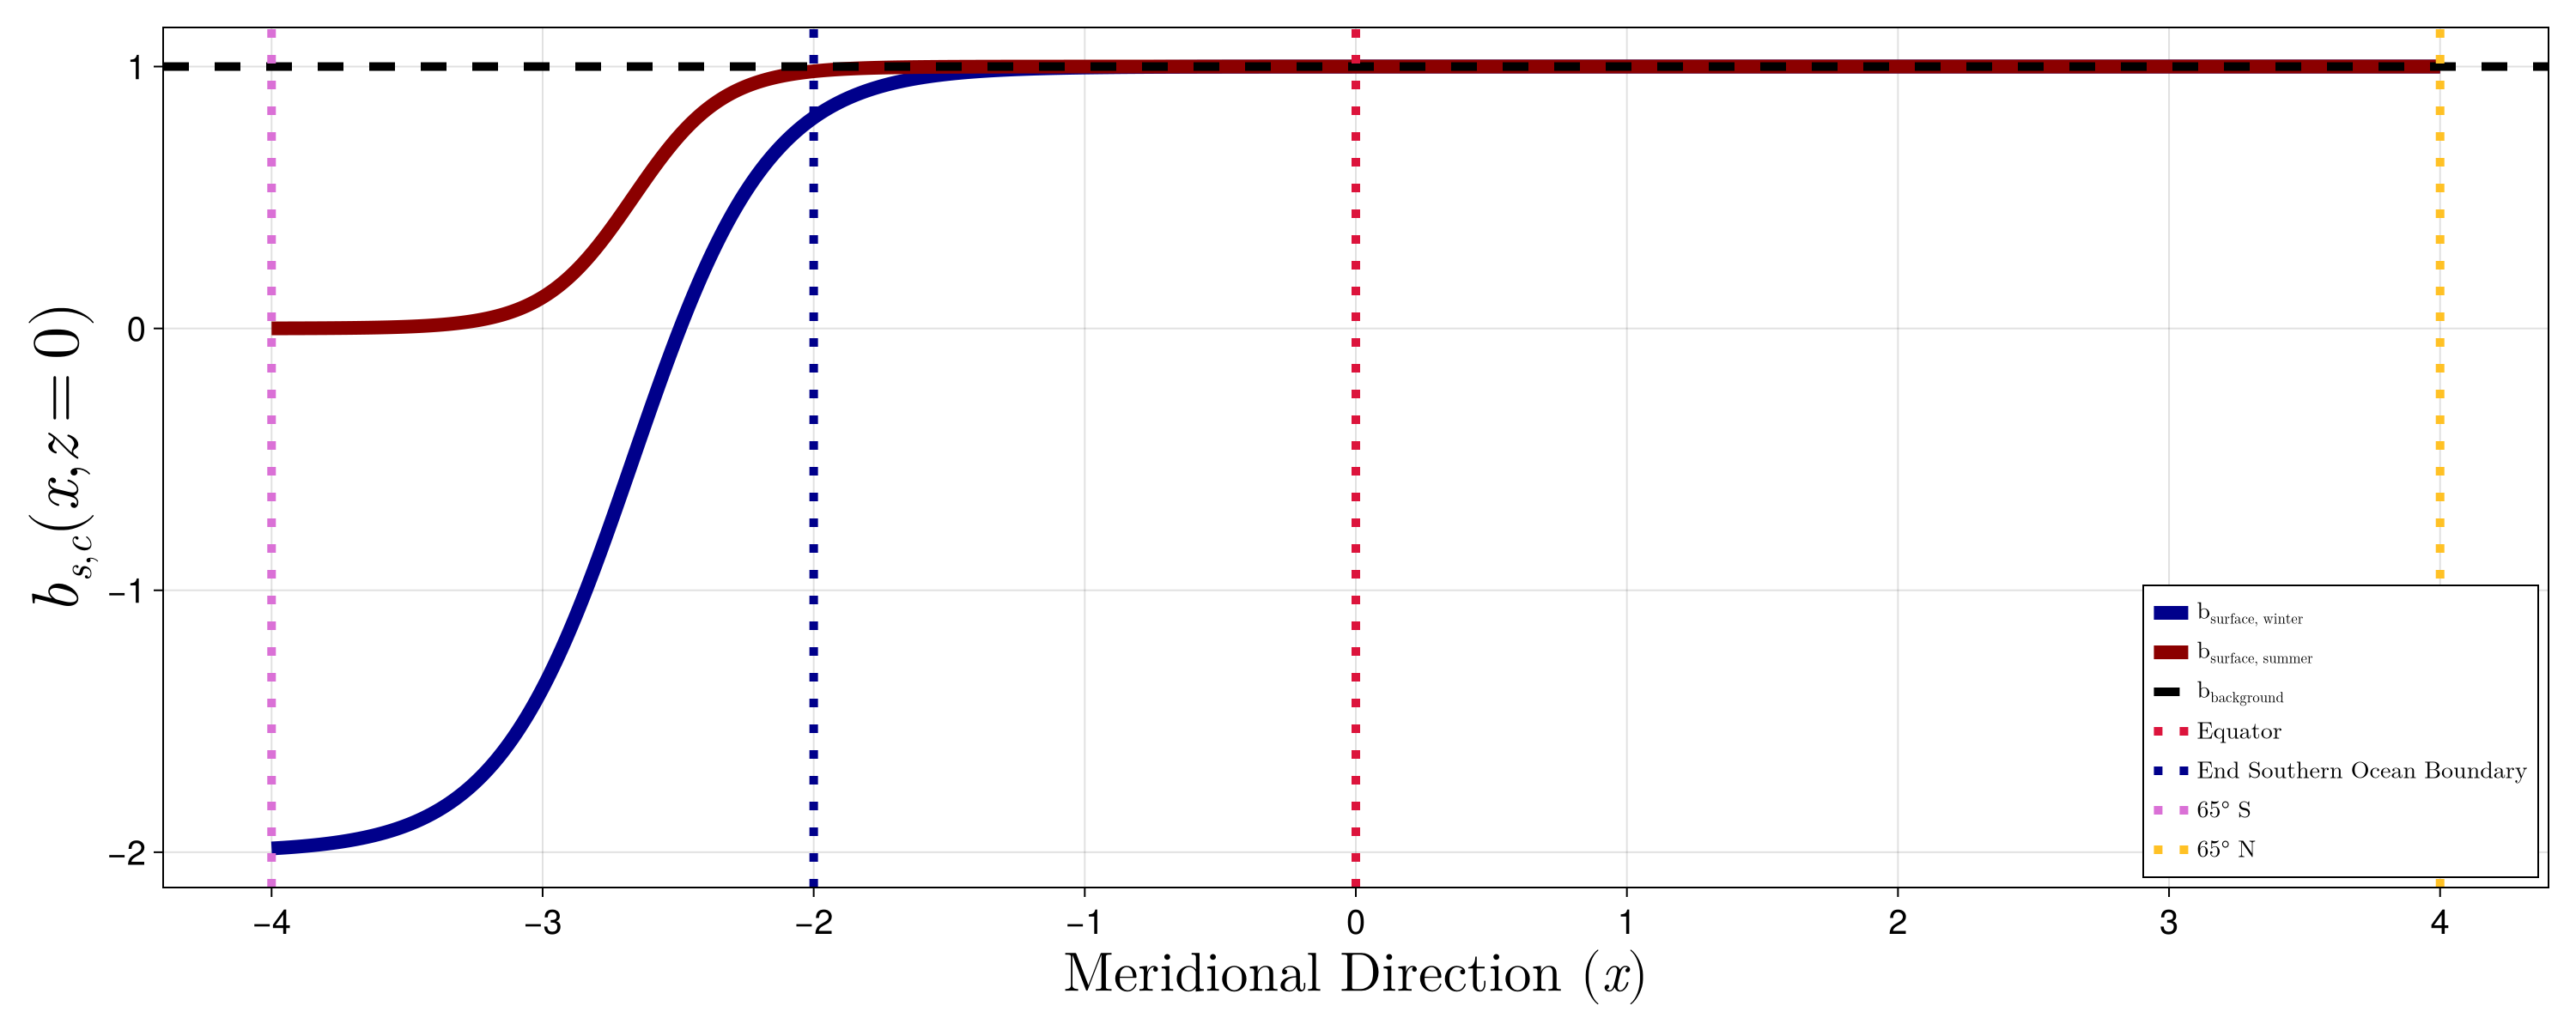

In [69]:
#plot chapter 2 forcing 
# Plot

b=1.0

f_fig = Figure(resolution=(1500, 600))
ax = Axis(f_fig[1, 1], 
            xlabel=L"\text{Meridional Direction } (x)", 
            ylabel=L"b_{s,c}(x, z=0)", 
            xticks = -L/2:1:L/2)
            #title="Scaled tanh Function for Surface Buoyancy Forcing")
#lines!(ax, x, y, linewidth=10, label=L"b_{s,c}(x)", color=:pink)
#lines!(ax, x, bsw.(x,b), color=:darkturquoise, label=L"\text{b_{s,winter}}", linewidth=8)
#lines!(ax, x, bss.(x,b), color=:orange, label=L"\text{b_{s,summer}}", linewidth=8)
lines!(ax, x, bsw.(x,b) .+ b, color=:darkblue, label=L"\text{b_{surface, winter}}", linewidth=8)
lines!(ax, x, bss.(x,b) .+ b, color=:darkred, label=L"\text{b_{surface, summer}}", linewidth=8)


# Reference lines
hlines!(ax, [1], linestyle=:dash, color=:black, linewidth=5, label=L"\text{b_{background}}")
vlines!(ax, [0], linestyle=:dot, color=:crimson, label=L"\text{Equator}", linewidth=5)
vlines!(ax, [-2], linestyle=:dot, color=:darkblue, label=L"\text{End Southern Ocean Boundary}", linewidth=5)
vlines!(ax, [-4], linestyle=:dot, color=:orchid, label=L"65°\text{ S}", linewidth=5)
vlines!(ax, [4], linestyle=:dot, color=:goldenrod1, label=L"65°\text{ N}", linewidth=5)

ax.xlabelsize = 32
ax.ylabelsize = 38
ax.xticklabelsize = 20
ax.yticklabelsize = 20

axislegend(ax, position=:rb)
f_fig

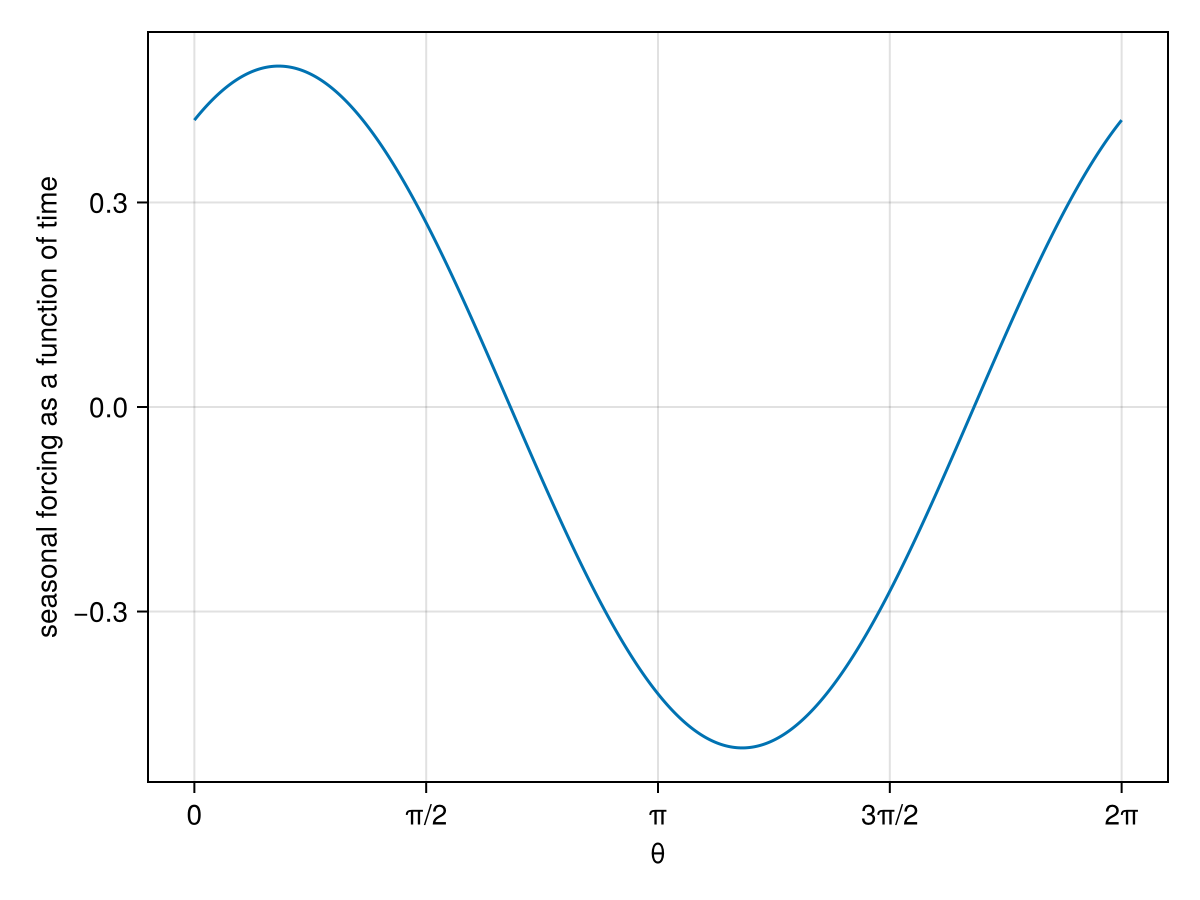

In [59]:
θ = range(0, 2π, length=1000)
seasonal_func = (sin.(θ .+ 1)) ./ 2

fig = Figure()
ax = Axis(fig[1,1], 
    xlabel = "θ",
    ylabel = "seasonal forcing as a function of time",
    xticks = (0:π/2:2π, ["0", "π/2", "π", "3π/2", "2π"]))
lines!(θ, seasonal_func)

fig


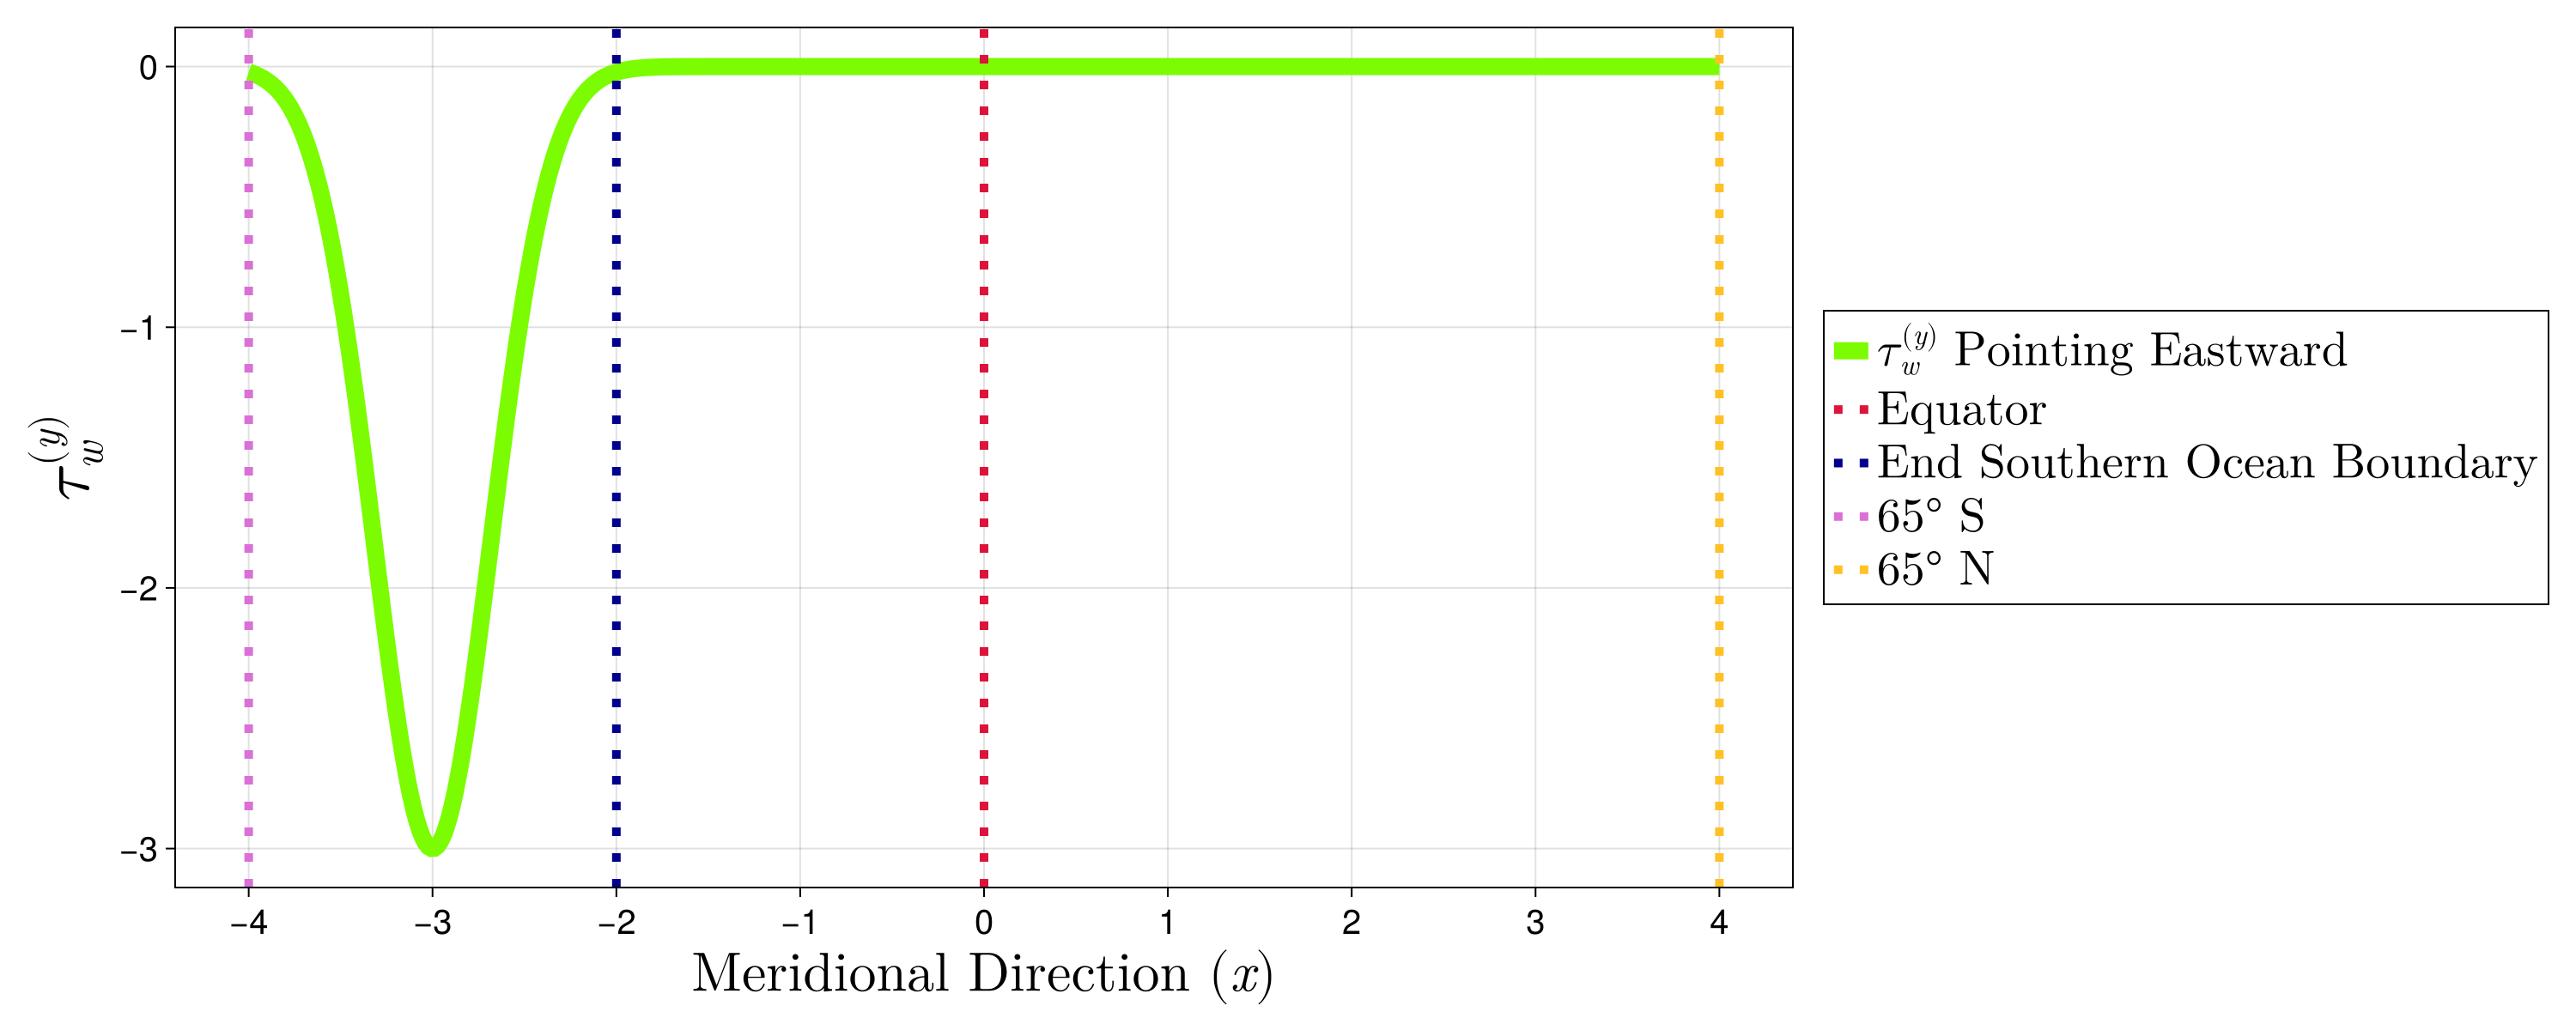

In [30]:
w = -3 # strength of wind forcing
σ = 0.45

function wind(x, w,  σ)
    return w * exp(- ((x+3L/8) / σ)^2)
end

x = range(-L/2, L/2; length=500)
y = wind.(x, w, σ)

#plot
fog = Figure(size=(1500, 600))
ax = Axis(fog[1, 1],
            xlabel=L"\text{Meridional Direction } (x)", 
            ylabel=L"\tau^{(y)}_w", 
            xticks = -L/2:1:L/2)
lines!(ax, x, y, linewidth=10, label=L"\tau^{(y)}_{w} \text{ Pointing Eastward}", color=:lawngreen)
ax.xlabelsize = 32
ax.ylabelsize = 40
ax.xticklabelsize = 20
ax.yticklabelsize = 20

vlines!(ax, [0], linestyle=:dot, color=:crimson, label=L"\text{Equator}", linewidth=5)
vlines!(ax, [-2], linestyle=:dot, color=:darkblue, label=L"\text{End Southern Ocean Boundary}", linewidth=5)
vlines!(ax, [-4], linestyle=:dot, color=:orchid, label=L"65°\text{ S}", linewidth=5)
vlines!(ax, [4], linestyle=:dot, color=:goldenrod1, label=L"65°\text{ N}", linewidth=5)

Legend(fog[1,2], ax, labelsize=28)

fog


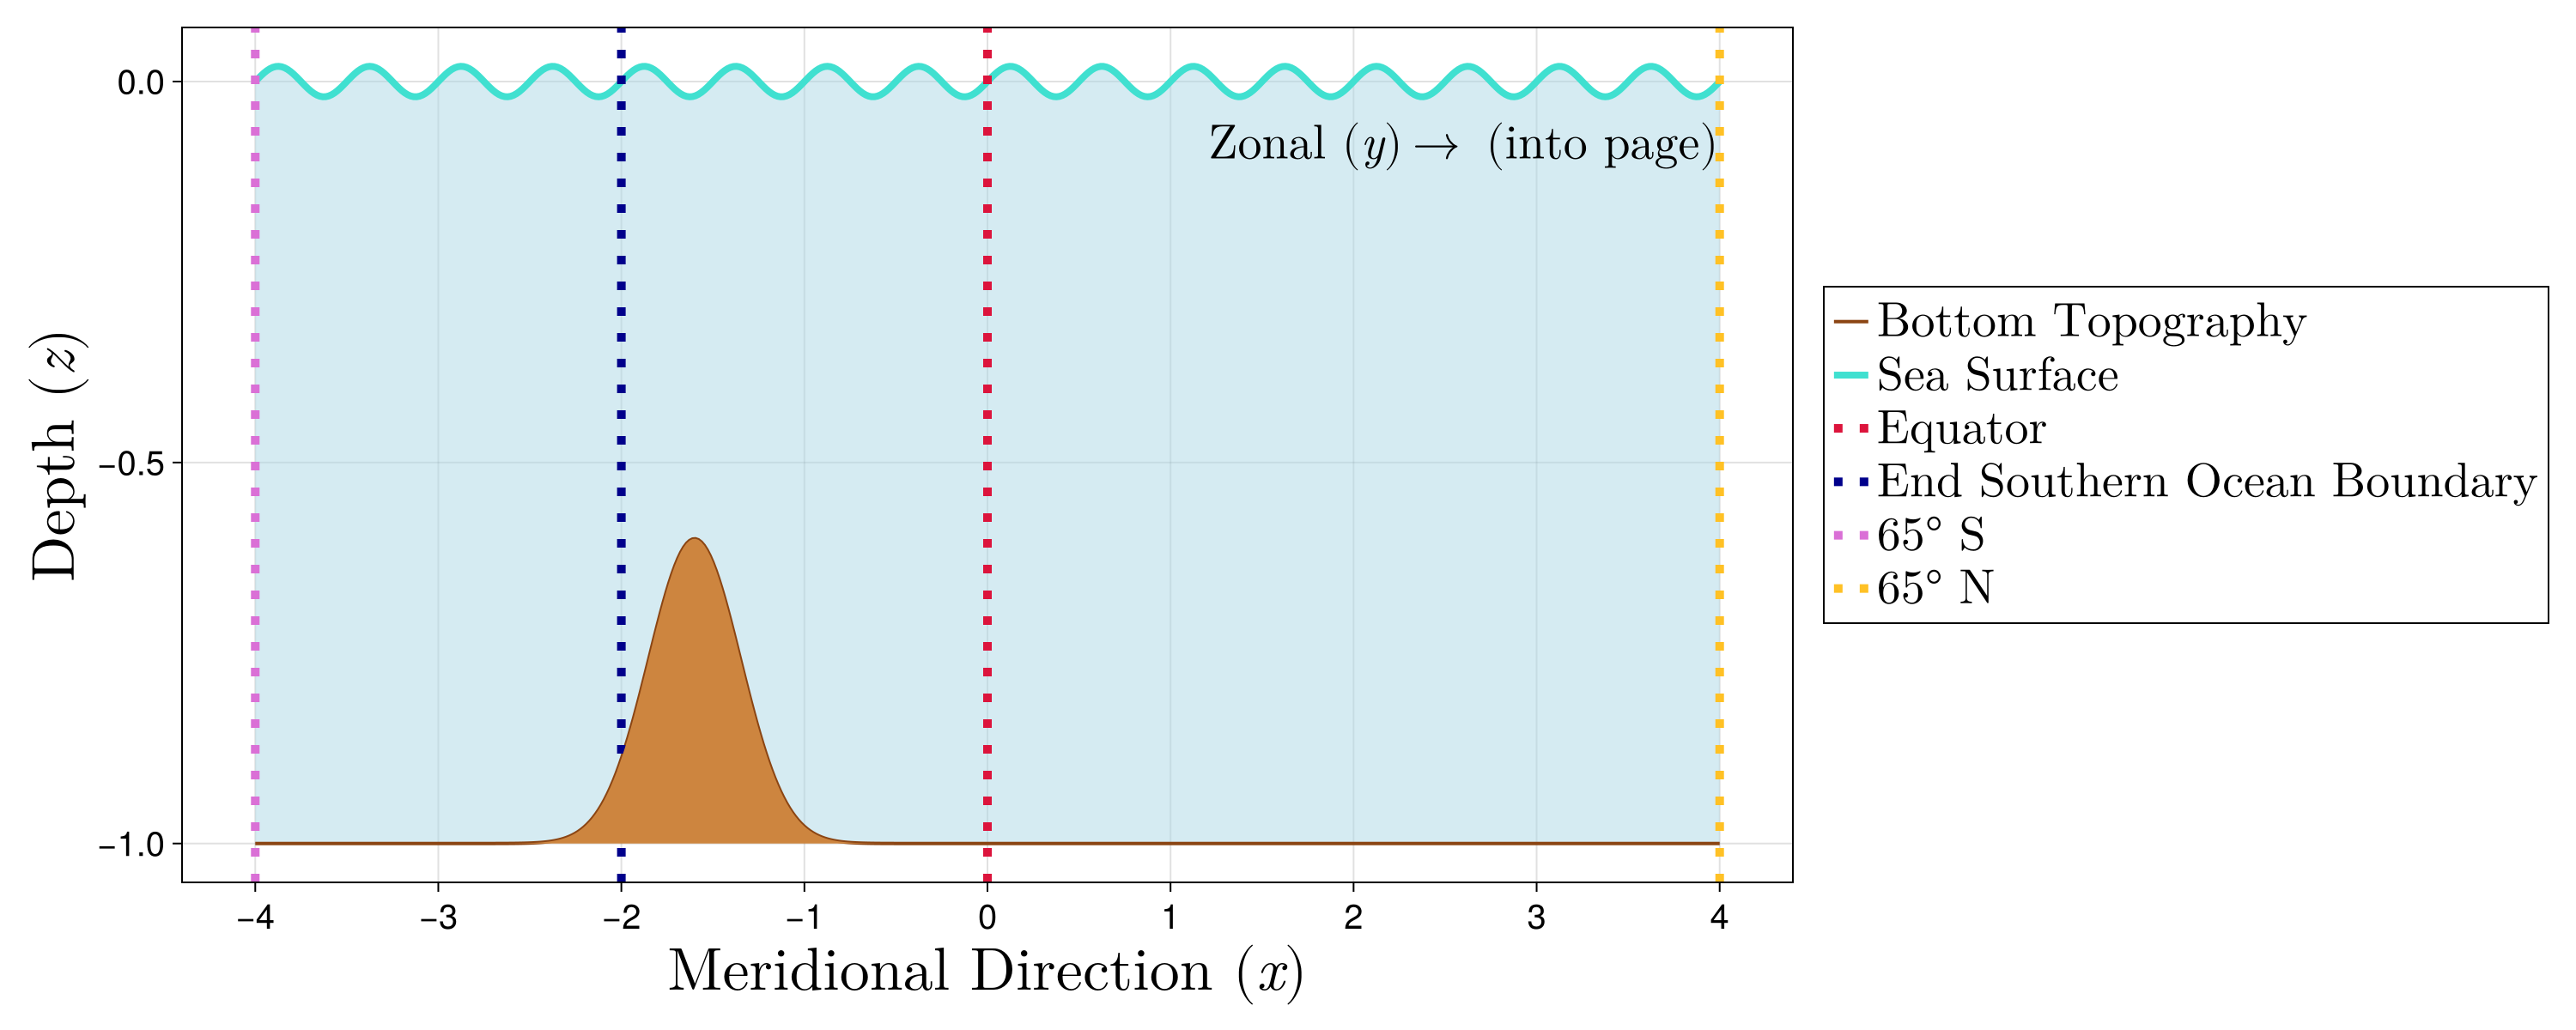

In [5]:
#schematic with hills
h₀_1 = 0.6
Lx = 8.0
H = 1.0 
hill_length = Lx/32
hill_xpos = -Lx/5
hill_1(x) = (2/3)*h₀_1 * exp(-(x- hill_xpos)^2 / (2*hill_length^2))
bottom = -H .+ hill_1.(x)

cute_lil_seasurf(x) = 0.02 * sin(4π*x)  # sine function for topography

fig = Figure(size=(1500, 600))
ax = Axis(fig[1, 1],
            xlabel=L"\text{Meridional Direction } (x)",
            ylabel = L"\text{Depth } (z)",
            xticks = -Lx/2:1:Lx/2)

#make ocean background blue
# ocean background from wavy surface to bottom
poly!(ax,
    vcat(Point2f.(x, cute_lil_seasurf.(x)),  # top edge (sea surface)
         reverse(Point2f.(x, bottom))        # bottom edge
    ),
    color = (:lightblue, 0.5)
)

#lines!(ax, x, fill(0.0, length(x)), color=:deepskyblue3, linewidth=4, label=L"\text{Sea Surface}")
lines!(ax, x, bottom, color=:saddlebrown, linewidth=2, label=L"\text{Bottom Topography}")
lines!(ax, x, cute_lil_seasurf.(x), color=:turquoise, linewidth=4, label=L"\text{Sea Surface }")

vlines!(ax, [0], linestyle=:dot, color=:crimson, label=L"\text{Equator}", linewidth=5)
vlines!(ax, [-2], linestyle=:dot, color=:darkblue, label=L"\text{End Southern Ocean Boundary}", linewidth=5)
vlines!(ax, [-4], linestyle=:dot, color=:orchid, label=L"65°\text{ S}", linewidth=5)
vlines!(ax, [4], linestyle=:dot, color=:goldenrod1, label=L"65°\text{ N}", linewidth=5)

#text!(ax, "Topographic Barrier", position=(hill_xpos+0.4, -H + hill_1(hill_xpos)+0.1), align = (:center, :bottom), fontsize=25, color=:saddlebrown)
#text!(ax, L"65° \text{ S}", position=(-Lx/2, -H+0.009), align = (:center, :top), fontsize = 24)
#text!(ax, L"65° \text{ N}", position=(Lx/2, -H+0.009), align = (:center, :top), fontsize = 24)
text!(ax, L"\text{Zonal } (y) \rightarrow \text{ (into page)}", position = (Lx/4+0.6, -0.05), align = (:center, :top), fontsize=28)

poly!(ax, Point2f.(x, bottom), color=:peru)
ax.xlabelsize = 35
ax.ylabelsize = 35
ax.xticklabelsize = 20
ax.yticklabelsize = 20
Legend(fig[1,2], ax, labelsize=28)
fig

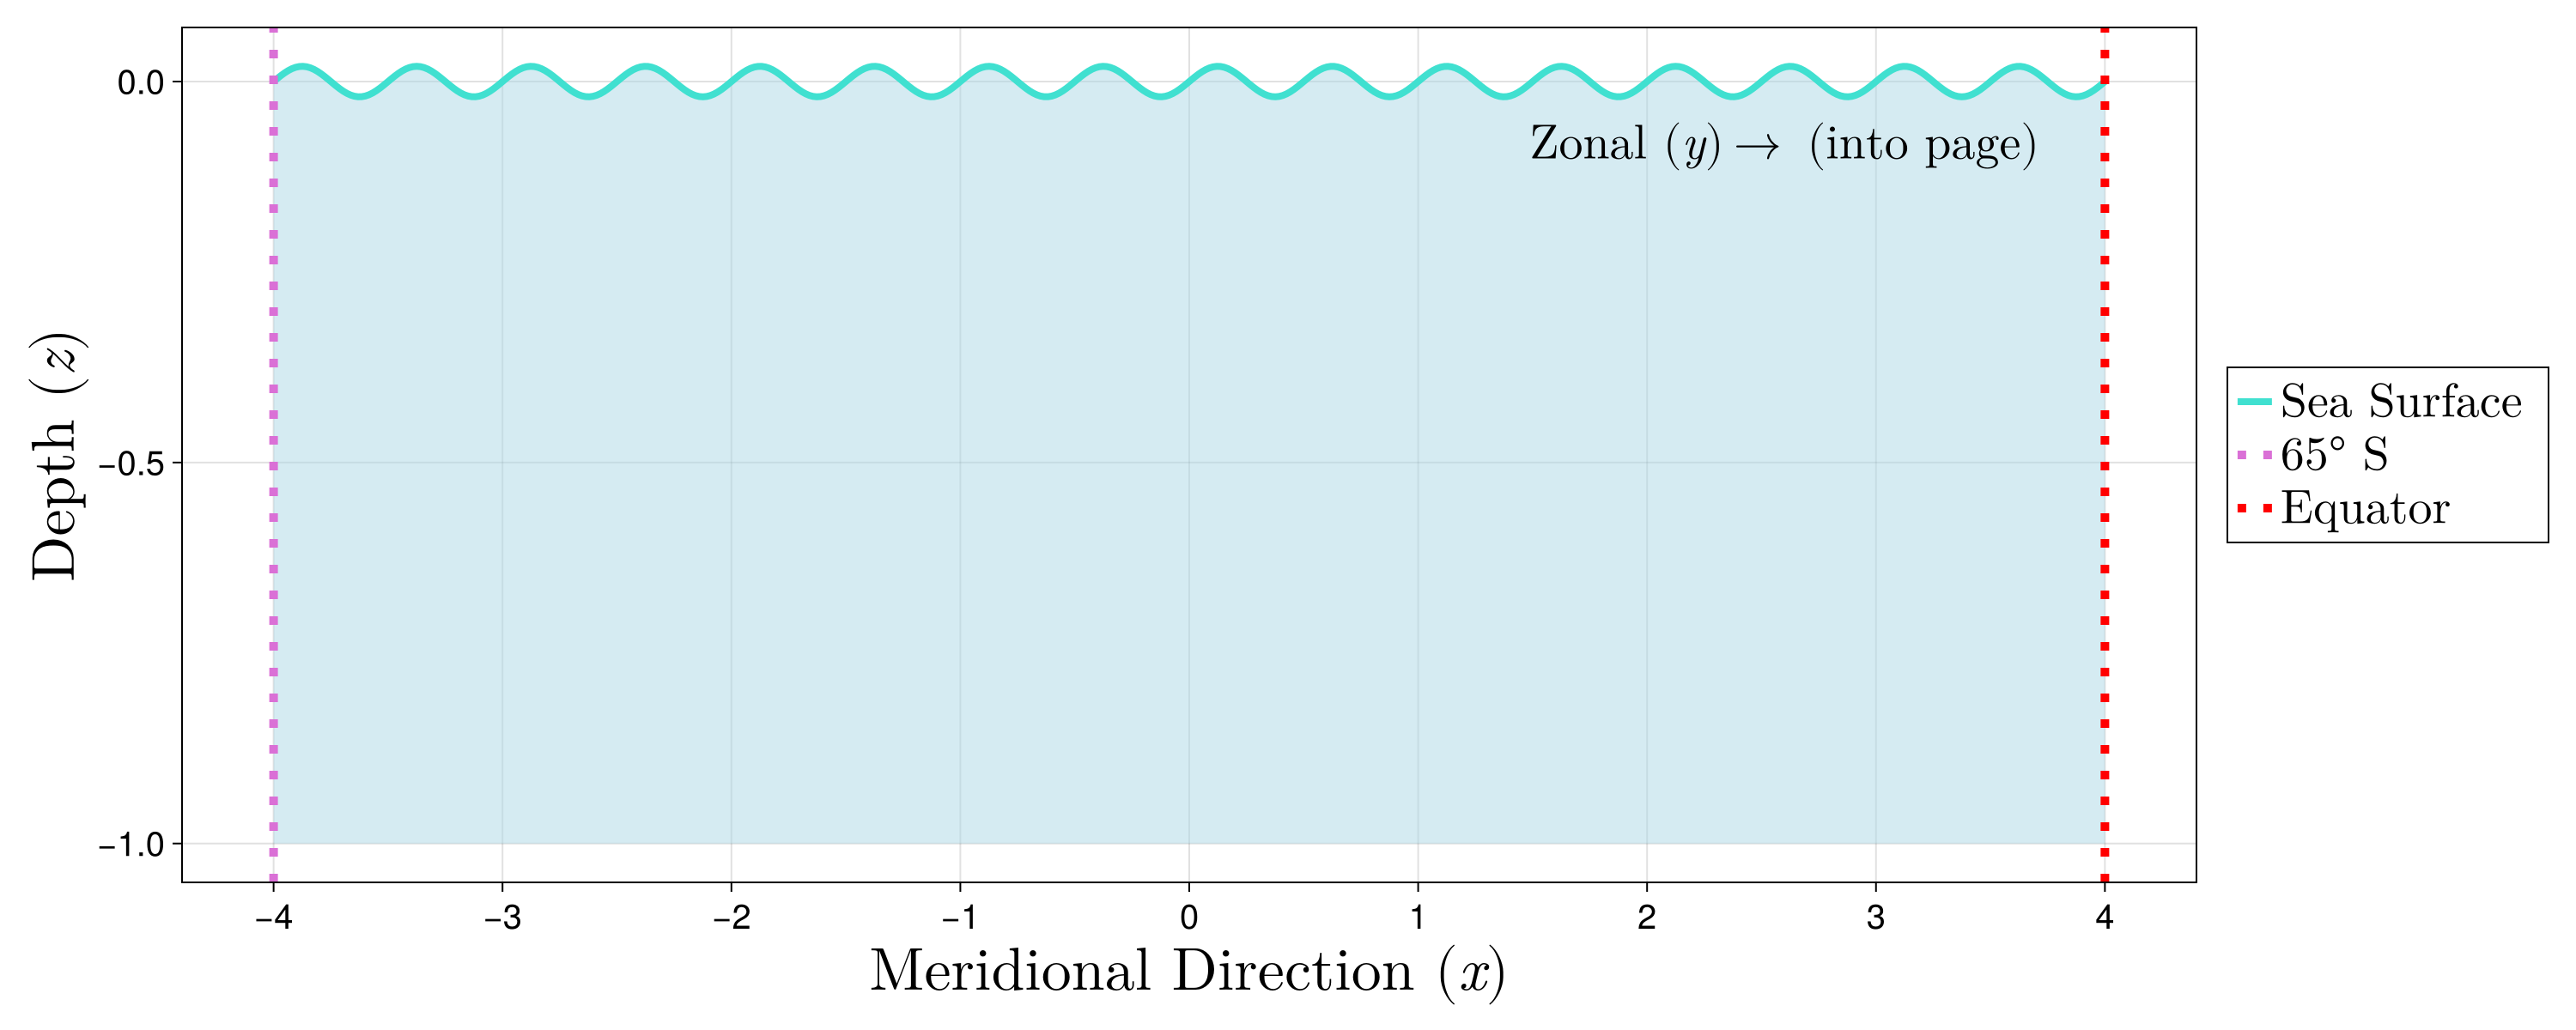

In [21]:
#schematic with hills
h₀_1 = 0.6
Lx = 8.0
H = 1.0 
hill_length = Lx/32
hill_xpos = -Lx/5
hill_1(x) = (2/3)*h₀_1 * exp(-(x- hill_xpos)^2 / (2*hill_length^2))
bottom = -H #.+ hill_1.(x)

cute_lil_seasurf(x) = 0.02 * sin(4π*x)  # sine function for topography

fig = Figure(size=(1500, 600))
ax = Axis(fig[1, 1],
            xlabel=L"\text{Meridional Direction } (x)",
            ylabel = L"\text{Depth } (z)",
            xticks = -Lx/2:1:Lx/2)

#make ocean background blue
# ocean background from wavy surface to bottom
poly!(ax,
    vcat(Point2f.(x, cute_lil_seasurf.(x)),  # top edge (sea surface)
         reverse(Point2f.(x, bottom))        # bottom edge
    ),
    color = (:lightblue, 0.5)
)

#lines!(ax, x, fill(0.0, length(x)), color=:deepskyblue3, linewidth=4, label=L"\text{Sea Surface}")
#lines!(ax, x, bottom, color=:saddlebrown, linewidth=2, label=L"\text{Bottom Topography}")
lines!(ax, x, cute_lil_seasurf.(x), color=:turquoise, linewidth=4, label=L"\text{Sea Surface }")

#vlines!(ax, [0], linestyle=:dot, color=:crimson, label=L"\text{Equator}", linewidth=5)
#lines!(ax, [-2], linestyle=:dot, color=:darkblue, label=L"\text{End Southern Ocean Boundary}", linewidth=5)
vlines!(ax, [-4], linestyle=:dot, color=:orchid, label=L"65°\text{ S}", linewidth=5)
vlines!(ax, [4], linestyle=:dot, color=:red, label=L"\text{Equator }", linewidth=5)

#text!(ax, "Topographic Barrier", position=(hill_xpos+0.4, -H + hill_1(hill_xpos)+0.1), align = (:center, :bottom), fontsize=25, color=:saddlebrown)
#text!(ax, L"65° \text{ S}", position=(-Lx/2, -H+0.009), align = (:center, :top), fontsize = 24)
#text!(ax, L"65° \text{ N}", position=(Lx/2, -H+0.009), align = (:center, :top), fontsize = 24)
text!(ax, L"\text{Zonal } (y) \rightarrow \text{ (into page)}", position = (Lx/4+0.6, -0.05), align = (:center, :top), fontsize=28)

poly!(ax, Point2f.(x, bottom), color=:peru)
ax.xlabelsize = 35
ax.ylabelsize = 35
ax.xticklabelsize = 20
ax.yticklabelsize = 20
Legend(fig[1,2], ax, labelsize=28)
fig